# **EDA: ESC-50**

**Fuente:** https://github.com/karolpiczak/ESC-50

El dataset ESC-50 es ideal para la clasificación de sonidos ambientales. Tiene **2,000 clips** de 5 segundos cada uno, organizados en **50 clases** y agrupados en **5 categorías**: animales, ruidos naturales, interior, exterior y actividades humanas.

| Campo | Valor |
|---|---|
| Clips | 2,000 |
| Clases | 50 |
| Duración por clip | 5 segundos (fija) |
| Sample rate | 44,100 Hz, mono, WAV |
| Folds | 5 |

### **Columnas del CSV (`meta/esc50.csv`)**

| Columna | Descripción |
|---|---|
| `filename` | Nombre del WAV (`{fold}-{clip_id}-{take}-{target}.wav`) |
| `fold` | Fold de validación cruzada (1–5) |
| `target` | ID numérico de clase (0–49) |
| `category` | Nombre de la clase |
| `esc10` | `True` si pertenece al subconjunto ESC-10 |
| `src_file` | ID del clip original en Freesound |
| `take` | Letra que distingue fragmentos del mismo clip fuente |

## **1. Carga del dataset**

In [ ]:
# Instalar dependencias (solo necesario en Colab)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "pandas", "matplotlib", "seaborn", "requests"], check=True)

import os, zipfile, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (11, 5)

# Descarga del dataset desde GitHub
ZIP_URL = "https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip"
ZIP_FILE = "ESC-50-master.zip"
EXTRACT_DIR = "."

if not os.path.exists("ESC-50-master"):
    print("Descargando ESC-50 (~600 MB)...")
    r = requests.get(ZIP_URL, stream=True)
    with open(ZIP_FILE, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile(ZIP_FILE, "r") as z:
        z.extractall(EXTRACT_DIR)
    os.remove(ZIP_FILE)
    print("Descarga completa.")
else:
    print("Dataset ya presente.")

# Carga del CSV de metadatos
META_PATH = "ESC-50-master/meta/esc50.csv"
df = pd.read_csv(META_PATH)

# Extraer info del filename
df["fold_fn"] = df["filename"].str.split("-").str[0].astype(int)
df["clip_id"] = df["filename"].str.split("-").str[1].astype(int)
df["take_fn"] = df["filename"].str.split("-").str[2]
df["target_fn"] = df["filename"].str.split("-").str[3].str.replace(".wav","").astype(int)

# Macrocategorías (definidas en el paper)
MACRO = {
    "Animals": list(range(0, 10)),
    "Natural soundscapes": list(range(10, 20)),
    "Human non-speech": list(range(20, 30)),
    "Interior/domestic": list(range(30, 40)),
    "Exterior/urban": list(range(40, 50)),
}
target_to_macro = {}
for name, ids in MACRO.items():
    for i in ids: target_to_macro[i] = name
df["macro_category"] = df["target"].map(target_to_macro)


Dataset ya presente.


In [ ]:
print(f"Shape: {df.shape}")

Shape: (2000, 12)


In [ ]:
df.head()

,filename,fold,target,category,esc10,src_file,take,fold_fn,clip_id,take_fn,target_fn,macro_category
0,1-100032-A-0.wav,1,0,dog,True,100032,A,1,100032,A,0,Animals
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,1,100038,A,14,Natural soundscapes
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A,1,100210,A,36,Interior/domestic
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B,1,100210,B,36,Interior/domestic
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A,1,101296,A,19,Natural soundscapes


In [ ]:
df.tail()

,filename,fold,target,category,esc10,src_file,take,fold_fn,clip_id,take_fn,target_fn,macro_category
1995,5-263831-B-6.wav,5,6,hen,False,263831,B,5,263831,B,6,Animals
1996,5-263902-A-36.wav,5,36,vacuum_cleaner,False,263902,A,5,263902,A,36,Interior/domestic
1997,5-51149-A-25.wav,5,25,footsteps,False,51149,A,5,51149,A,25,Human non-speech
1998,5-61635-A-8.wav,5,8,sheep,False,61635,A,5,61635,A,8,Animals
1999,5-9032-A-0.wav,5,0,dog,True,9032,A,5,9032,A,0,Animals


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   filename        2000 non-null   object
 1   fold            2000 non-null   int64 
 2   target          2000 non-null   int64 
 3   category        2000 non-null   object
 4   esc10           2000 non-null   bool  
 5   src_file        2000 non-null   int64 
 6   take            2000 non-null   object
 7   fold_fn         2000 non-null   int64 
 8   clip_id         2000 non-null   int64 
 9   take_fn         2000 non-null   object
 10  target_fn       2000 non-null   int64 
 11  macro_category  2000 non-null   object
dtypes: bool(1), int64(6), object(5)
memory usage: 174.0+ KB


## **2. Estructura y tipos de datos**

In [ ]:
df.columns

Index(['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take',
       'fold_fn', 'clip_id', 'take_fn', 'target_fn', 'macro_category'],
      dtype='object')

In [ ]:
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
filename,0
fold,0
target,0
category,0
esc10,0
src_file,0
take,0
fold_fn,0
clip_id,0
take_fn,0


In [ ]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [ ]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
filename,0
fold,0
target,0
category,0
esc10,0
src_file,0
take,0
fold_fn,0
clip_id,0
take_fn,0


In [ ]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
filename,0.0
fold,0.0
target,0.0
category,0.0
esc10,0.0
src_file,0.0
take,0.0
fold_fn,0.0
clip_id,0.0
take_fn,0.0


In [ ]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
filename,object
fold,int64
target,int64
category,object
esc10,bool
src_file,int64
take,object
fold_fn,int64
clip_id,int64
take_fn,object


In [ ]:
print("Estadísticas descriptivas")
df.describe(include="all").T

Estadísticas descriptivas


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
filename,2000,2000,5-261325-A-9.wav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fold,2000.0,NaN,NaN,NaN,3.0,1.414567,1.0,2.0,3.0,4.0,5.0
target,2000.0,NaN,NaN,NaN,24.5,14.434479,0.0,12.0,24.5,37.0,49.0
category,2000,50,dog,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
esc10,2000,2,False,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_file,2000.0,NaN,NaN,NaN,137696.7975,64882.993641,137.0,87726.25,143745.5,188215.0,264453.0
take,2000,8,A,1527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fold_fn,2000.0,NaN,NaN,NaN,3.0,1.414567,1.0,2.0,3.0,4.0,5.0
clip_id,2000.0,NaN,NaN,NaN,137696.7975,64882.993641,137.0,87726.25,143745.5,188215.0,264453.0
take_fn,2000,8,A,1527,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['filename', 'category', 'take', 'take_fn', 'macro_category'], dtype='object')

## **3. Balance de clases**


- El dataset está **perfectamente balanceado**: hay exactamente **40 clips por clase**.
- Esto lo hace ideal para métricas simples como accuracy sin necesidad de class weights.


Clips por clase - min: 40, max: 40, único valor: True


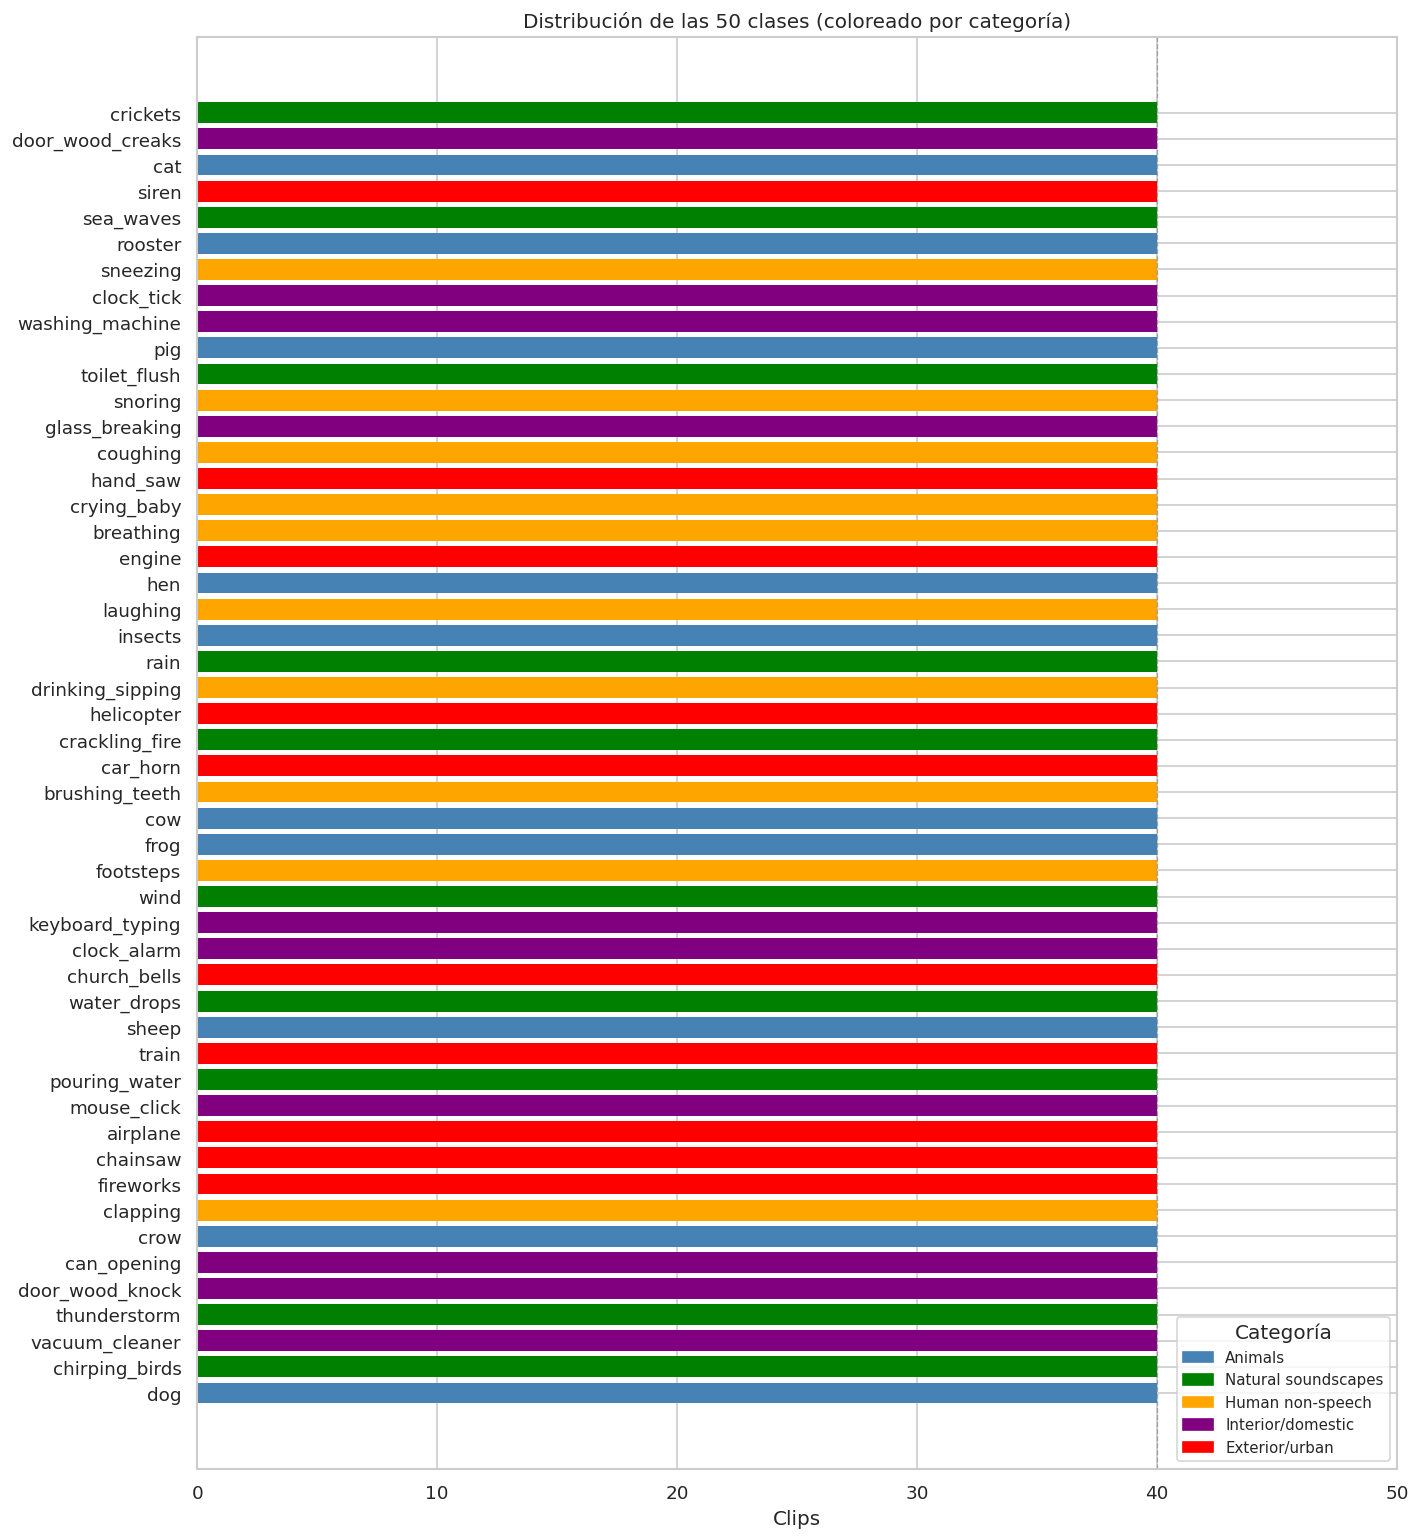

In [ ]:
class_counts = df["category"].value_counts()
print(f"Clips por clase - min: {class_counts.min()}, max: {class_counts.max()}, único valor: {class_counts.nunique() == 1}")

# Color por categoría
macro_colors = {
    "Animals": "steelblue",
    "Natural soundscapes": "green",
    "Human non-speech": "orange",
    "Interior/domestic": "purple",
    "Exterior/urban": "red",
}
cat_to_macro = df.drop_duplicates("category").set_index("category")["macro_category"].to_dict()
colors = [macro_colors[cat_to_macro[c]] for c in class_counts.index]

fig, ax = plt.subplots(figsize=(12, 13))
bars = ax.barh(class_counts.index, class_counts.values, color=colors, edgecolor="none")
ax.set_xlabel("Clips")
ax.set_title("Distribución de las 50 clases (coloreado por categoría)")
ax.set_xlim(0, 50)
ax.axvline(40, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in macro_colors.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9, title="Categoría")
plt.tight_layout()
plt.show()


## **4. Distribución por categoría**

- Las 50 clases se agrupan en 5 categorías con 10 clases (400 clips) cada una.

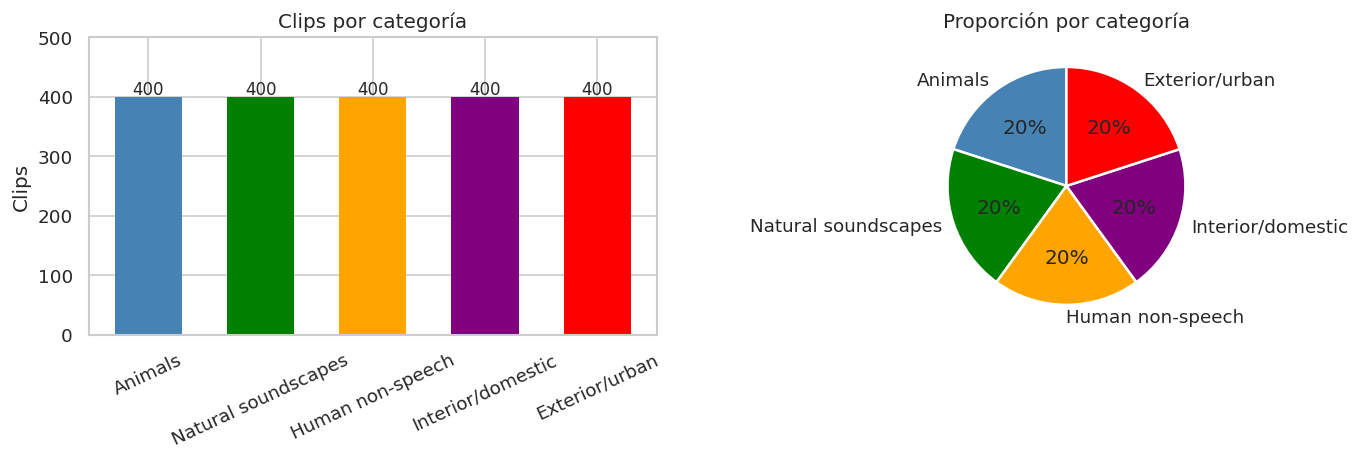

In [ ]:
macro_counts = df["macro_category"].value_counts().reindex(MACRO.keys())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
colors_macro = list(macro_colors.values())
axes[0].bar(macro_counts.index, macro_counts.values,
            color=colors_macro, edgecolor="none", width=0.6)
axes[0].set_title("Clips por categoría")
axes[0].set_ylabel("Clips")
axes[0].tick_params(axis="x", rotation=25)
for x, y in zip(range(len(macro_counts)), macro_counts.values):
    axes[0].text(x, y + 5, str(y), ha="center", fontsize=10)
axes[0].set_ylim(0, 500)

# Pie
axes[1].pie(macro_counts.values, labels=macro_counts.index,
            colors=colors_macro, autopct="%1.0f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Proporción por categoría")
plt.tight_layout()
plt.show()

## **5. Distribución por fold**


- ESC-50 tiene **exactamente 400 clips por fold** (5 folds × 400 = 2,000).
- La división garantiza que fragmentos del mismo `src_file` estén en el mismo fold (sin data leakage).

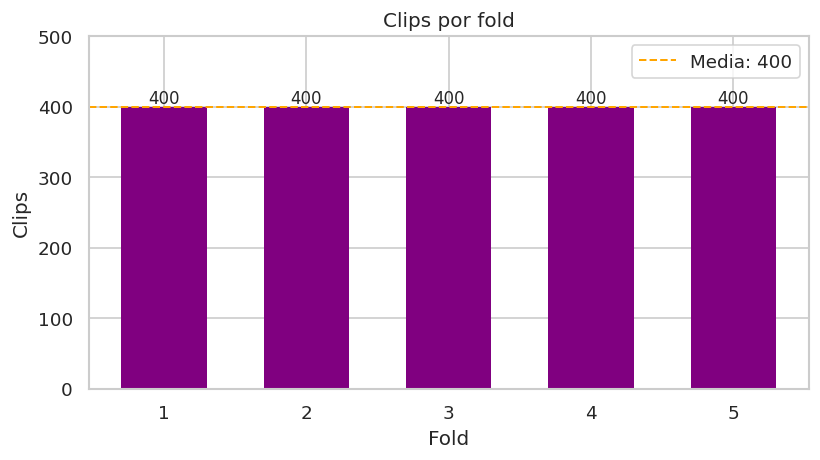

In [ ]:
fold_counts = df["fold"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(fold_counts.index, fold_counts.values, color="purple",
       edgecolor="none", width=0.6)
ax.axhline(fold_counts.mean(), color="orange", linestyle="--",
           linewidth=1.2, label=f"Media: {fold_counts.mean():.0f}")
for x, y in zip(fold_counts.index, fold_counts.values):
    ax.text(x, y + 5, str(y), ha="center", fontsize=10)
ax.set_xlabel("Fold")
ax.set_ylabel("Clips")
ax.set_title("Clips por fold")
ax.set_xticks(range(1, 6))
ax.set_ylim(0, 500)
ax.legend()
plt.tight_layout()
plt.show()

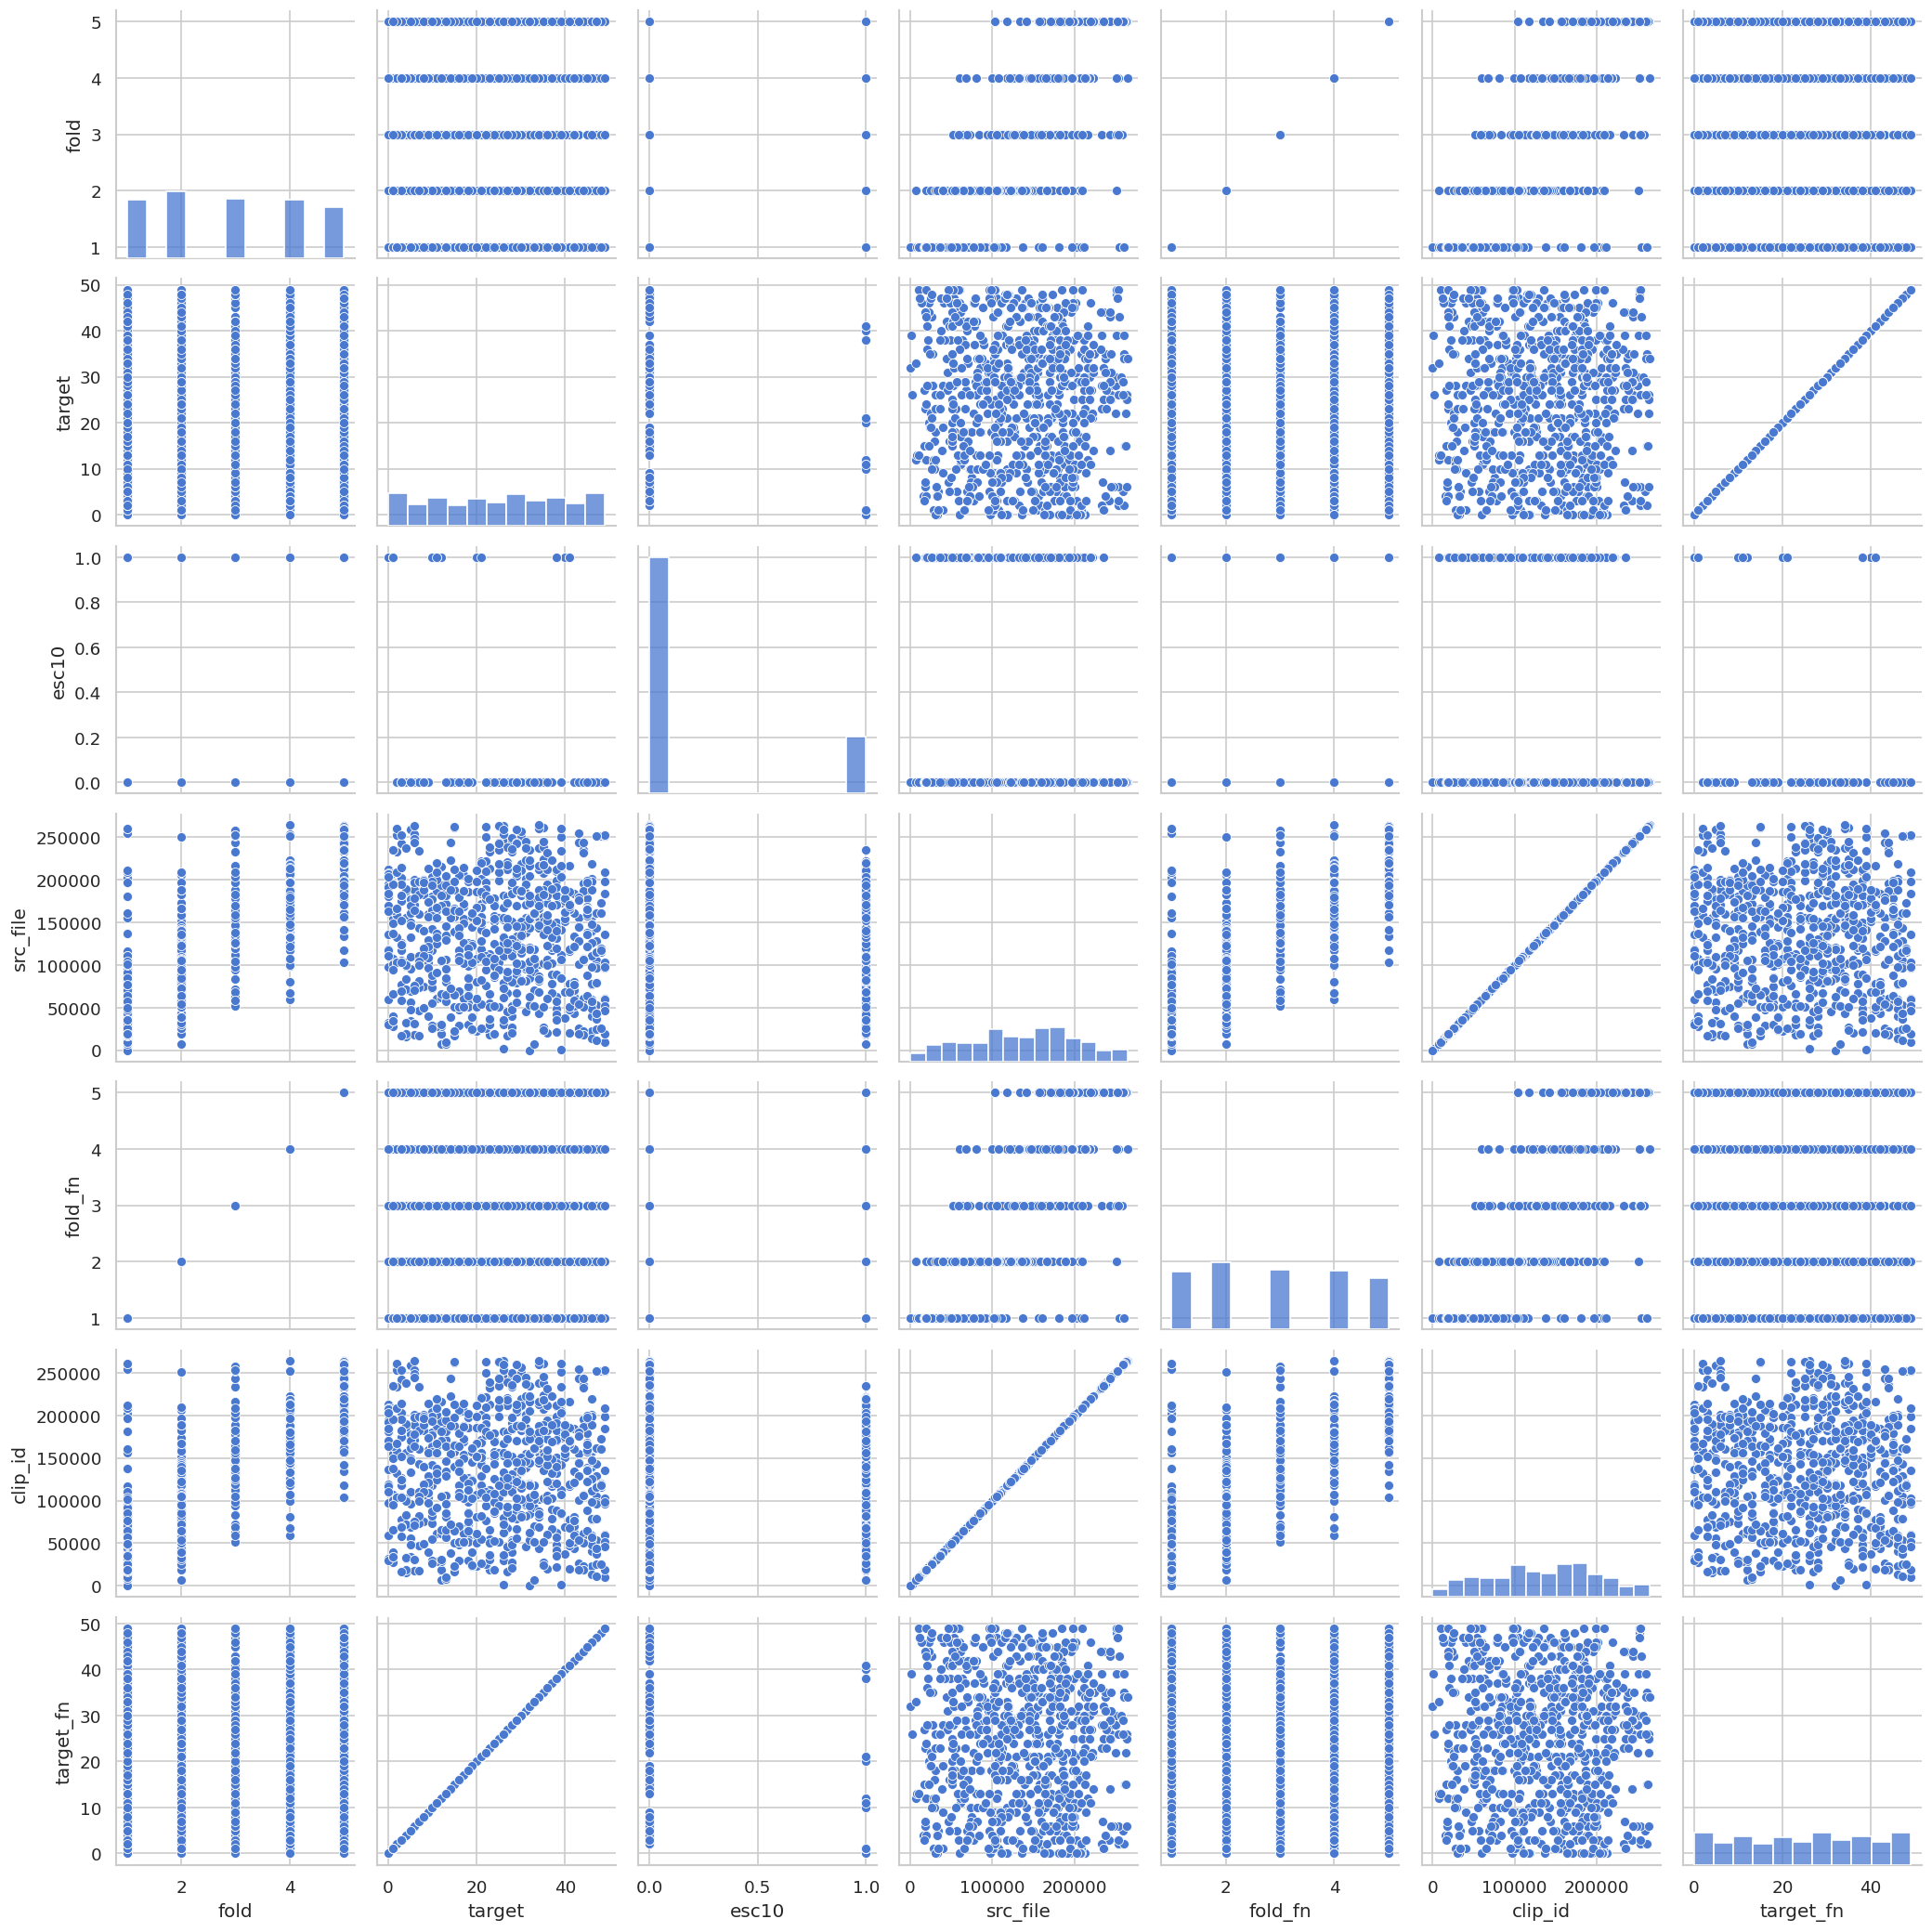

In [ ]:
sns.pairplot(data=df.sample(1000))
plt.tight_layout()
plt.show()

## **6. Clases × fold (heatmap)**

- Cada clase tiene exactamente **8 clips por fold**; es una distribución perfectamente uniforme.

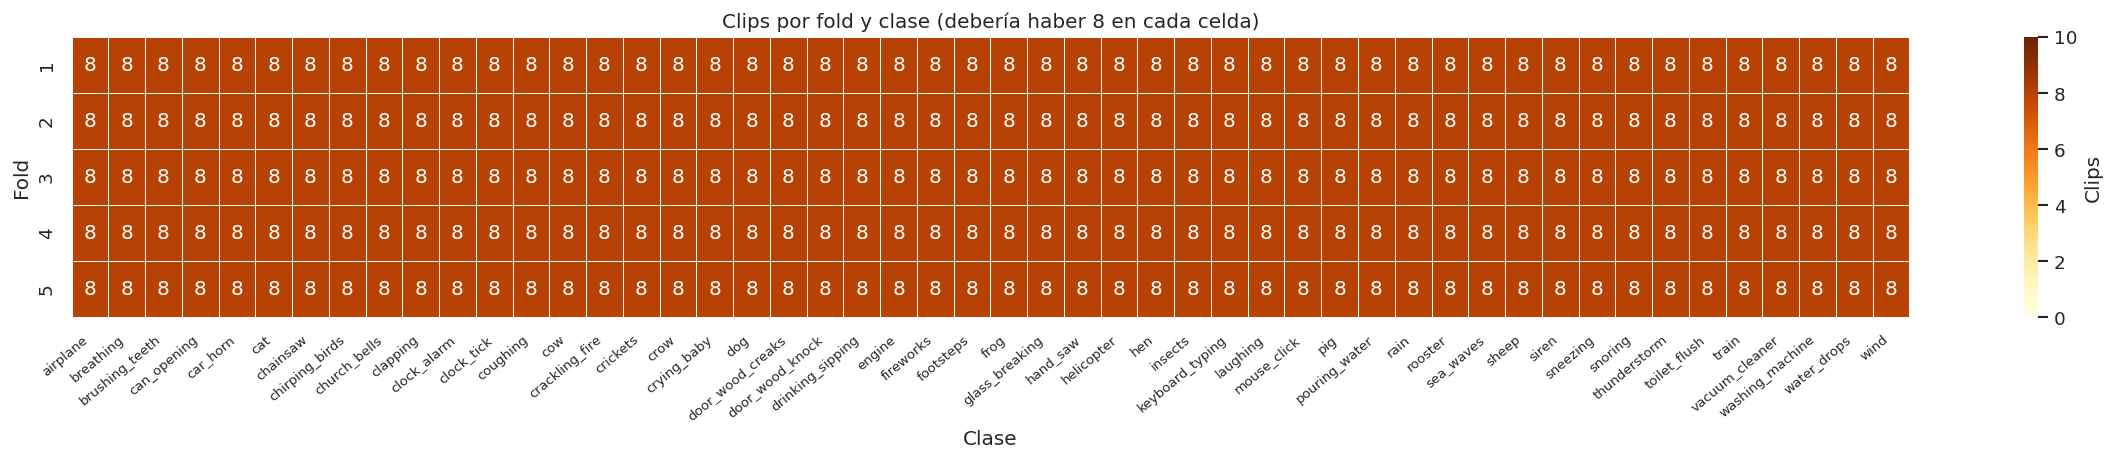

In [ ]:
pivot = df.groupby(["fold", "category"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(20, 4))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrBr",
            linewidths=0.3, ax=ax, cbar_kws={"label": "Clips"},
            vmin=0, vmax=10)
ax.set_title("Clips por fold y clase (debería haber 8 en cada celda)")
ax.set_xlabel("Clase")
ax.set_ylabel("Fold")
plt.xticks(rotation=40, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

## **7. Subconjunto ESC-10**

- El ESC-10 es un subconjunto de **10 clases seleccionadas** con licencia CC BY (más permisiva).  
- Es útil para experimentos rápidos o proyectos que requieren licencia comercial.

Clases en ESC-10 (10):
chainsaw                  [Exterior/urban]
clock_tick                [Interior/domestic]
crackling_fire            [Natural soundscapes]
crying_baby               [Human non-speech]
dog                       [Animals]
helicopter                [Exterior/urban]
rain                      [Natural soundscapes]
rooster                   [Animals]
sea_waves                 [Natural soundscapes]
sneezing                  [Human non-speech]

Total clips ESC-10: 400 (20% del dataset)


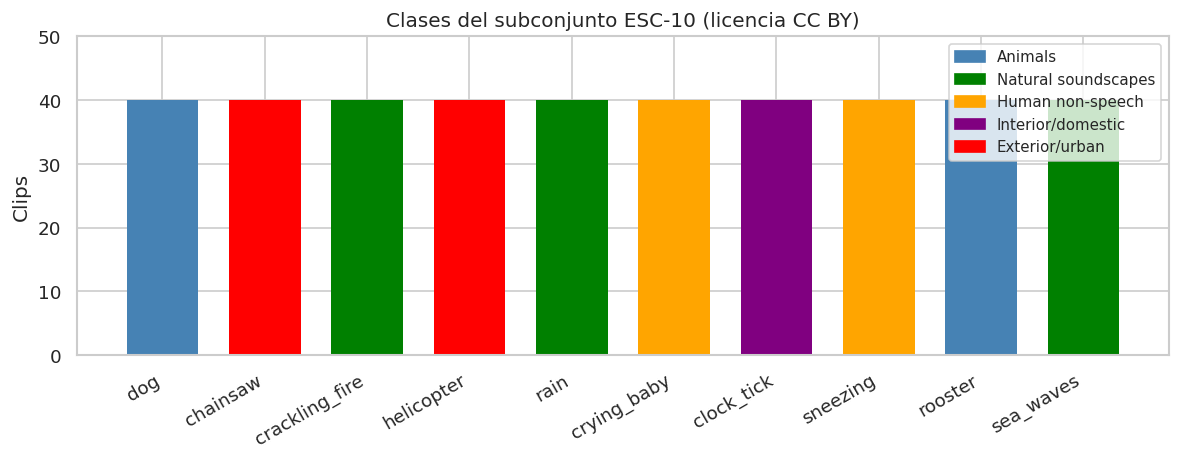

In [ ]:
esc10_classes = df[df["esc10"] == True]["category"].unique()
print(f"Clases en ESC-10 ({len(esc10_classes)}):")
for c in sorted(esc10_classes):
    macro = cat_to_macro[c]
    print(f"{c:<25} [{macro}]")

print(f"\nTotal clips ESC-10: {df['esc10'].sum()} ({df['esc10'].mean()*100:.0f}% del dataset)")

# Visualizar cuáles son
esc10_counts = df[df["esc10"] == True]["category"].value_counts()
colors_esc10 = [macro_colors[cat_to_macro[c]] for c in esc10_counts.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(esc10_counts.index, esc10_counts.values,
       color=colors_esc10, edgecolor="none", width=0.7)
ax.set_title("Clases del subconjunto ESC-10 (licencia CC BY)")
ax.set_ylabel("Clips")
ax.set_ylim(0, 50)
plt.xticks(rotation=30, ha="right")

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in macro_colors.items()
                  if k in [cat_to_macro[c] for c in esc10_counts.index]]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.show()

## **8. Fuentes originales (src_file)**

- El dataset garantiza que todos los clips de un mismo `src_file` caen en el mismo fold, evitando data leakage. Es importante respetarlo al hacer splits manuales.

Fuentes únicas por fold:
fold
1    311
2    302
3    308
4    297
5    310

Total fuentes únicas: 1524
Media de clips por fuente: 1.31


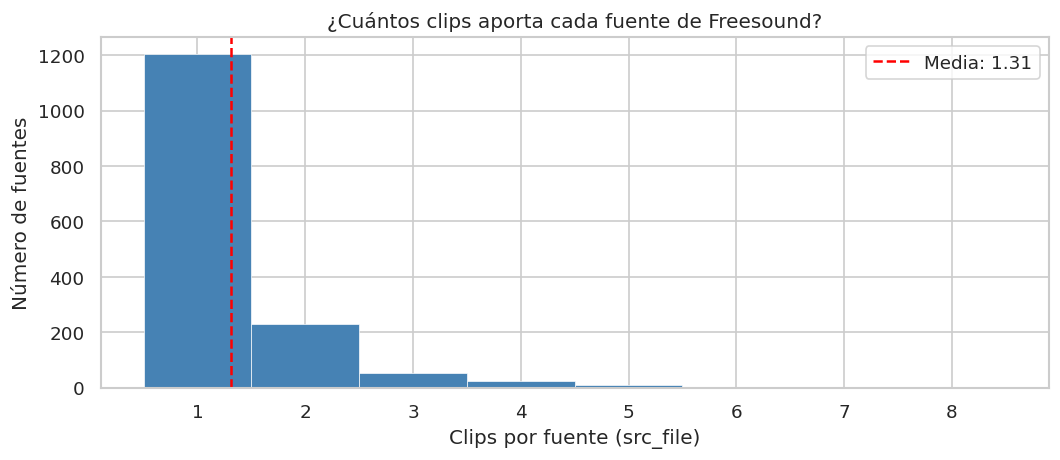

In [ ]:
src_per_fold = df.groupby("fold")["src_file"].nunique()
print("Fuentes únicas por fold:")
print(src_per_fold.to_string())
print(f"\nTotal fuentes únicas: {df['src_file'].nunique()}")
print(f"Media de clips por fuente: {df.groupby('src_file').size().mean():.2f}")

# Distribución de clips por fuente
clips_per_src = df.groupby("src_file").size()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(clips_per_src.values, bins=range(1, clips_per_src.max() + 2),
        color="steelblue", edgecolor="white", linewidth=0.4, align="left")
ax.set_xlabel("Clips por fuente (src_file)")
ax.set_ylabel("Número de fuentes")
ax.set_title("¿Cuántos clips aporta cada fuente de Freesound?")
ax.axvline(clips_per_src.mean(), color="red", linestyle="--",
           label=f"Media: {clips_per_src.mean():.2f}")
ax.legend()
plt.tight_layout()
plt.show()

## **9. Takes (fragmentos por fuente)**

- El campo `take` (A, B, C...) distingue distintos fragmentos extraídos del mismo audio fuente.

Distribución de takes:
take
A    1527
B     317
C      88
D      38
E      15
F       7
G       5
H       3


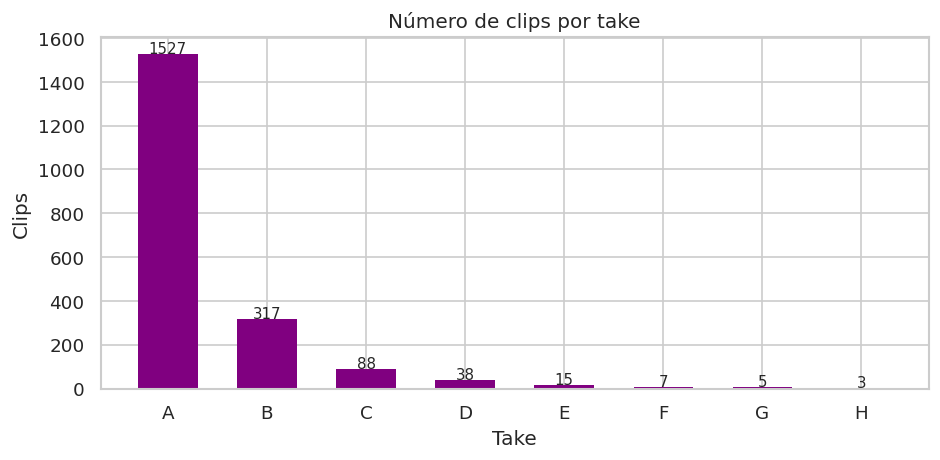

In [ ]:
take_counts = df["take"].value_counts().sort_index()
print("Distribución de takes:")
print(take_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(take_counts.index, take_counts.values, color="purple", edgecolor="none", width=0.6)
ax.set_title("Número de clips por take")
ax.set_xlabel("Take")
ax.set_ylabel("Clips")
for x, y in zip(range(len(take_counts)), take_counts.values):
    ax.text(x, y + 5, str(y), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## **10. Duración de los clips (con librosa)**

- Todos los clips deberían medir exactamente 5 segundos (44,100 × 5 = 220,500 muestras).
- La siguiente celda lo verifica leyendo los WAVs reales con `librosa`.
- Tarda unos minutos al procesar 2,000 archivos.

count    2000.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
Name: duration_s, dtype: float64

Clips que NO duran 5 segundos: 0


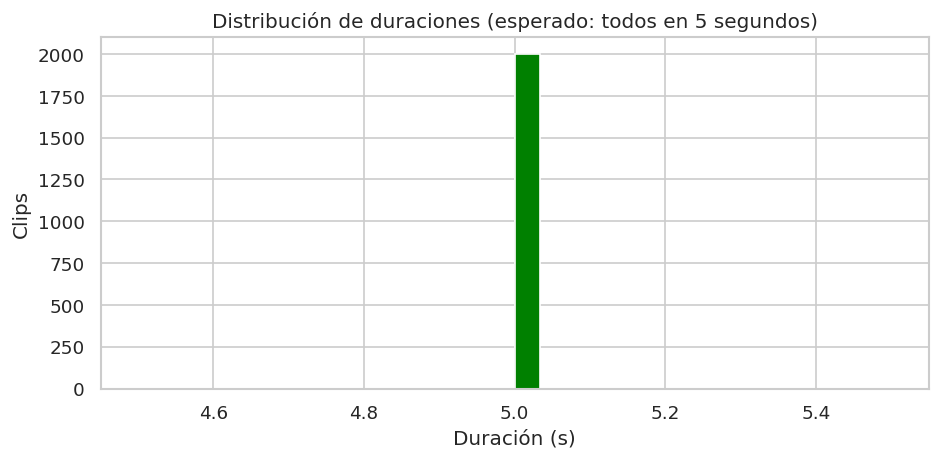

In [ ]:
import librosa

AUDIO_DIR = "ESC-50-master/audio"

durations = []
for fname in df["filename"]:
    path = os.path.join(AUDIO_DIR, fname)
    try:
        y, sr = librosa.load(path, sr=None, mono=True)
        durations.append(len(y) / sr)
    except Exception:
        durations.append(np.nan)

df["duration_s"] = durations

print(df["duration_s"].describe().round(4))
n_non5 = (df["duration_s"] - 5.0).abs().gt(0.05).sum()
print(f"\nClips que NO duran 5 segundos: {n_non5}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["duration_s"].dropna(), bins=30, color="green", edgecolor="white")
ax.set_xlabel("Duración (s)")
ax.set_ylabel("Clips")
ax.set_title("Distribución de duraciones (esperado: todos en 5 segundos)")
plt.tight_layout()
plt.show()

## **11. Resumen**

| Hallazgo | ¿Qué implica? |
|---|---|
| Dataset perfectamente balanceado (40 clips por clase) | Se puede usar accuracy directamente, sin class weights |
| Duración fija de 5 segundos | Espectrogramas de tamaño fijo |
| 5 folds bien construidos (400 clips c/u) | Usar 5-fold CV estrictamente; no crear splits propios |
| Sin valores nulos | No se requiere imputación |

